In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
df_sorted=pd.read_excel('../../../data/processed/RNA/BTM_terms.xlsx', index_col=0)

In [3]:
df_sorted['abs_FDR']=df_sorted['FDR q-val'].abs()
df_sorted['FDR']=df_sorted['FDR q-val']

In [4]:
df_sorted=df_sorted.sort_values('NES', ascending=False)

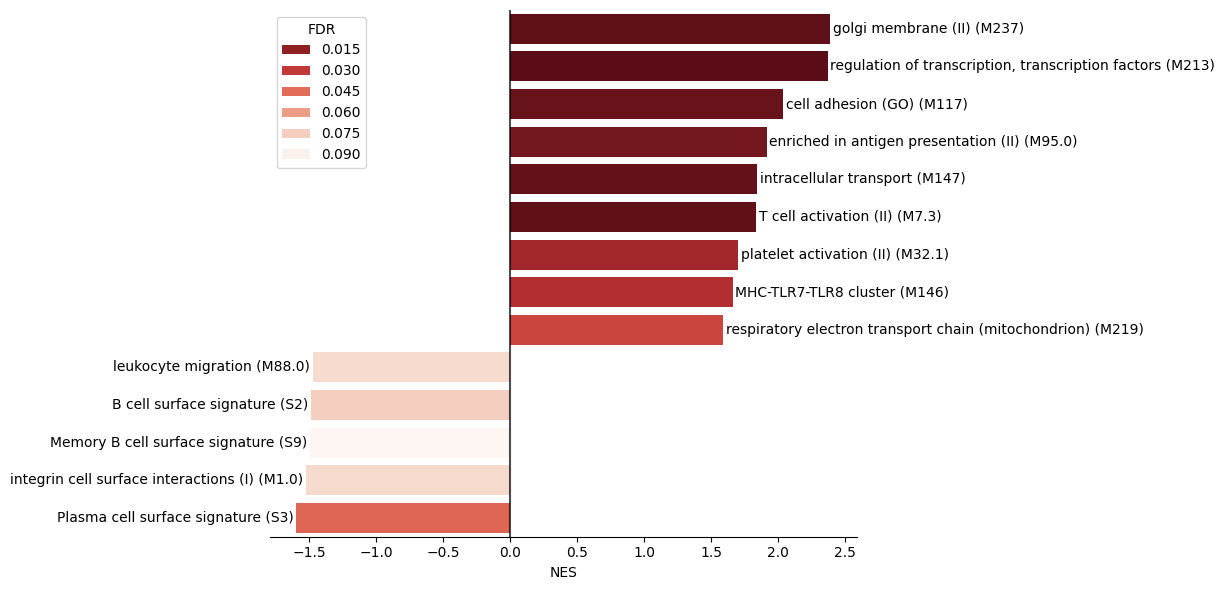

In [5]:
plt.figure(figsize=(12,6))



ax= sns.barplot(df_sorted[df_sorted.abs_FDR<0.2], x='NES', y=np.arange(len(df_sorted[df_sorted.abs_FDR<0.2])), orient='h', hue='FDR', palette='Reds_r')
# Add term labels at the tip of each bar
for i, (idx, row) in enumerate(df_sorted[df_sorted.abs_FDR<0.2].iterrows()):
    x_pos = row['NES']
    # Adjust text position slightly beyond the bar tip
    offset = 0.02 if x_pos >= 0 else -0.02
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, i, row['Term'], va='center', ha=ha, fontsize=10)
    
# Remove y-axis
ax.set_ylabel('')
ax.set_yticks([])

# Add vertical line at NES=0
ax.axvline(x=0, color='black', linestyle='-', alpha=0.7)
sns.despine()
ax.spines['left'].set_visible(False)  # Remove left spine
ax.tick_params(left=False)  # Remove y-axis tick marks

plt.tight_layout()    
#plt.savefig('topics_BTM.svg')